# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.model_selection import (
    KFold, cross_val_predict, GridSearchCV,
    train_test_split, learning_curve
)
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error,
    root_mean_squared_error, median_absolute_error, r2_score
)


In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Problem Definition and Data Collection

A real estate agency needs a tool that estimates a residential sale price from observable characteristics. This is supervised regression: given features $\mathbf{x}$, predict the realised price $y \in \mathbb{R}^{+}$.

Records were collected from `domain.com.au`. Two page types were used:
- **index cards:** price, date, type, beds, baths, parking, area

- **individual listing pages:** sale method, agency, agent, feature tags,marketing description, and frequently an area the card omits.

Every retained property has **both**.

In [3]:
df_full = pd.read_csv("../data/sydney_housing.csv")
df_full["sold_date"] = pd.to_datetime(df_full["sold_date"])
print(f"{len(df_full)} properties collected x {df_full.shape[1]} columns")

239 properties collected x 39 columns


## Missing values: inspection and handling

We inspect missingness across all collected properties before deciding what to keep.

**Strategy.** We shall handle missingness by two different approaches, described as below.

1. **Row removal**: Dropping all rows whose one of the column includes missing values. However, we restrict the removal so that, at the end, we still obtain more than 100 properties with at least 30 properties in each suburb. In later section, we shall benchmark our chosen models on raw dataset (239 rows) and filtered dataset (188 rows), which lays the foundation for this approach.

2. **Imputation inside the modelling pipeline**: After the above-mentioned approach, `area_sqm` is the single source of missingness. Its remaining gaps are filled from each training fold's median, never from held-out rows, so no leakage is introduced.

In [4]:
miss = pd.DataFrame({
    "n_missing": df_full.isna().sum(),
    "pct_missing": (df_full.isna().mean() * 100).round(1)
})
miss.sort_values("pct_missing", ascending = False).head(8)

,n_missing,pct_missing
area_sqm,84,35.1
sold_date_listing,31,13.0
parking,17,7.1
sale_method,9,3.8
agent,3,1.3
features,2,0.8
bedrooms,1,0.4
property_id,0,0.0


Fortunately, three of those six columns are not model inputs, so we may expect this does not adversely impact our modelling predictive capabilities.

In [5]:
REQUIRED = ["sold_date_listing", "parking", "sale_method", "agent", "features", "bedrooms"]

df = df_full.dropna(subset = REQUIRED).reset_index(drop = True)

print(f"{len(df_full)} collected -> {len(df)} retained")
print(dict(df.suburb.value_counts()))

239 collected -> 188 retained
{'Blacktown': np.int64(79), 'Chatswood': np.int64(62), 'Mosman': np.int64(47)}


In [6]:
miss = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1)
})
miss.sort_values("pct_missing", ascending = False).head(5)

,n_missing,pct_missing
area_sqm,64,34.0
property_id,0,0.0
area_is_internal,0,0.0
area_implausible,0,0.0
description,0,0.0


After the rule above, `area_sqm` is the only column with any missing values left, so handling is confined to it. That handling is postponed to the modelling stage rather than done here. Because imputing now would use statistics computed over rows that later become validation folds, which is leakage. Inside the pipeline the imputer is refit on each training fold alone.

In [7]:
view = df.groupby(["suburb", "property_type"]).size().unstack(fill_value = 0)
view.assign(total = lambda t: t.sum(axis = 1))
view.assign(total = lambda t: t.sum(axis = 1))

property_type,Apartment,House,Retirement living,Semi-detached,Townhouse,Villa,total
suburb,,,,,,,
Blacktown,25,47,0,0,6,1,79
Chatswood,48,13,0,0,1,0,62
Mosman,28,11,2,2,4,0,47


In [8]:
df_dtypes = (
    df.columns.to_series()
      .groupby(df.dtypes)
      .agg(", ".join)
      .to_frame("Columns")
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", None
):
    display(df_dtypes)

,Columns
int64,"property_id, listing_id, postcode, price_aud, date_source_disagrees, days_since_epoch, bathrooms, area_is_internal, area_multivalued, area_implausible, description_wordcount, feature_count, seifa_irsad_decile, seifa_irsd_decile, seifa_ieo_decile, seifa_ier_decile, suburb_urp_2021, suburb_median_house_3bed, suburb_median_unit_2bed, suburb_sales_12m"
datetime64[ns],sold_date
float64,"bedrooms, parking, area_sqm, seifa_irsad_score, seifa_irsd_score"
object,"source_url, source_site, retrieved_at, address, suburb, sold_date_listing, sale_method, property_type, area_source, description, features, agency, agent"


# Data Understanding and Feature Engineering

## Price distribution

We shall inspect how price are distributed. More specifically, we will inspect the distributions in its raw scale and in the log-scale, as it may uncover interesting patterns in the price distribution in the log-scale.

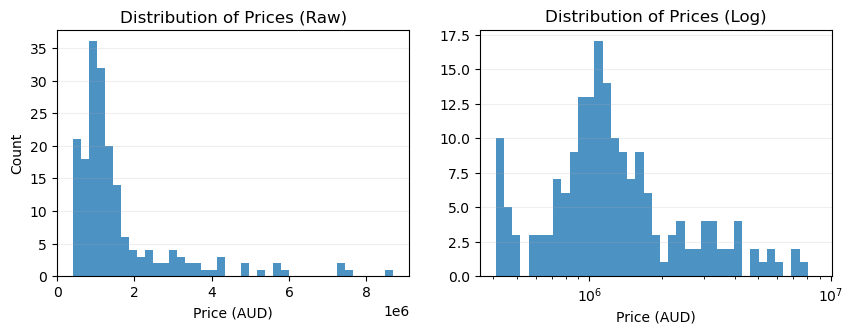

In [9]:
fig, ax = plt.subplots(1, 2, figsize = (10, 3.2))

price = df["price_aud"].dropna()
sns.histplot(
    price,
    bins = 40,
    ax = ax[0],
    color = "tab:blue",
    edgecolor = "none",
    alpha = 0.8
)
ax[0].set_title("Distribution of Prices (Raw)")
ax[0].set_xlabel("Price (AUD)")
ax[0].grid(axis="y", alpha=0.2)


bins = np.logspace(np.log10(price.min()), np.log10(price.max()), 40)
sns.histplot(
    price,
    bins = bins,
    ax = ax[1],
    color = "tab:blue",
    edgecolor = "none",
    alpha = 0.8
)

ax[1].set_title("Distribution of Prices (Log)")
ax[1].set_xscale("log")
ax[1].set_xlabel("Price (AUD)")
ax[1].set_ylabel("")
ax[1].grid(axis = "y", alpha = 0.2)


As can be seen from the plots above, the price is heavily right-skewed, suggesting a tiny portion of houses are priced highly.

## Price distributions in each surburb

Since the price distributions are right-skewed, we shall visualise the boxplot in both raw and log scales, and divide the price by $10^6$, for sake of better visualisation.

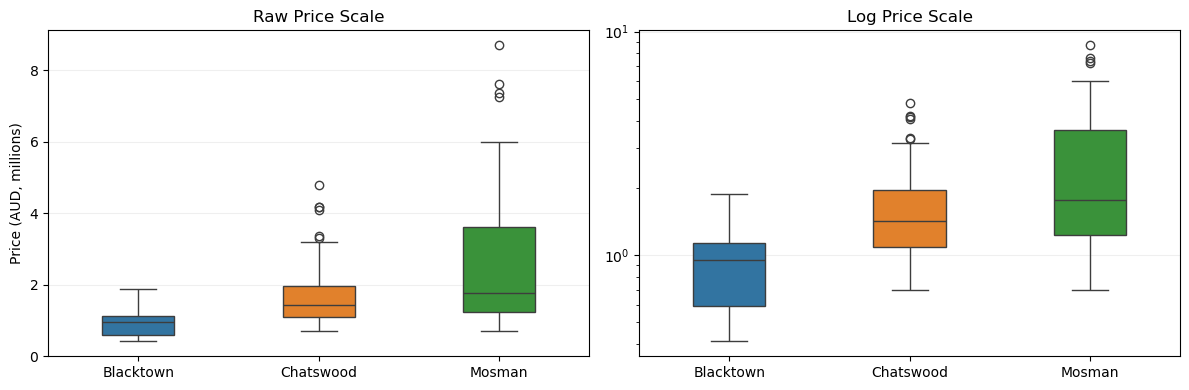

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

order = (
    df.groupby("suburb")["price_aud"]
      .median()
      .sort_values()
      .index
)

# Raw scale
sns.boxplot(
    data = df,
    x = "suburb",
    hue = "suburb",
    y = df["price_aud"]/1e6,
    order = order,
    width = 0.4,
    ax = ax[0]
)

ax[0].set_title("Raw Price Scale")
ax[0].set_xlabel("")
ax[0].set_ylabel("Price (AUD, millions)")
ax[0].tick_params(axis="x")
ax[0].grid(axis = "y", alpha = 0.2)

# Log scale
sns.boxplot(
    data = df,
    x = "suburb",
    hue = "suburb",
    y = df["price_aud"]/1e6,
    order = order,
    width = 0.4,
    ax = ax[1]
)

ax[1].set_yscale("log")
ax[1].set_title("Log Price Scale")
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].tick_params(axis="x")
ax[1].grid(axis = "y", alpha = 0.2)

plt.tight_layout()

In [11]:
df.groupby("suburb")["price_aud"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
suburb,,,,,,,,
Blacktown,79.0,901570.28,334345.03,410000.0,590000.0,950000.0,1130000.0,1881000.0
Chatswood,62.0,1716667.55,970869.27,700000.0,1082500.0,1417500.0,1950750.0,4800000.0
Mosman,47.0,2737882.98,2116701.57,700000.0,1228750.0,1760000.0,3612500.0,8700000.0


## Median price over time

Since the price distributions are right-skewed, we shall use the median for less misleading interpretations. Now, we investigate how pricing chages across the temporal dimension by observing their patterns each month.

In [12]:
month = (df.assign(mth = df["sold_date"].dt.to_period('M').dt.to_timestamp())
         .groupby(["mth", "suburb"])["price_aud"]
        )
med_prices = month.median().unstack()
counts = month.size().unstack()

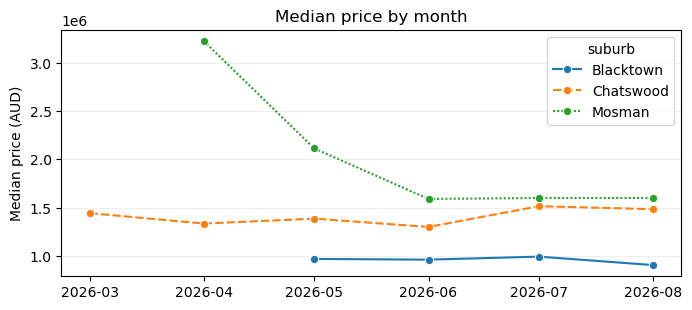

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.2))

sns.lineplot(data = med_prices, ax = ax, marker = "o")

ax.set_title("Median price by month")
ax.set_ylabel("Median price (AUD)")
ax.set_xlabel("")
ax.grid(axis = "y", alpha = 0.2)


In [14]:
counts.fillna(0).astype(int)

suburb,Blacktown,Chatswood,Mosman
mth,,,
2026-03-01,0,15,0
2026-04-01,0,18,6
2026-05-01,14,17,18
2026-06-01,20,7,15
2026-07-01,37,3,5
2026-08-01,8,2,3


## Correlation investigation

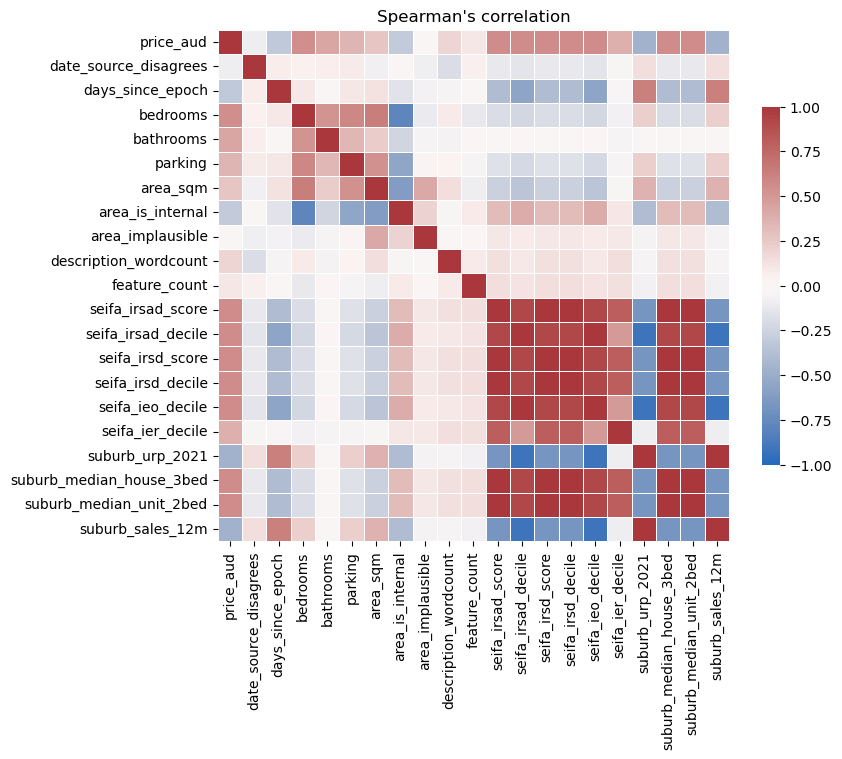

In [15]:
# Numeric predictors only; ids and the target are excluded.
feat = df.select_dtypes("number").drop(columns=["property_id", "listing_id", "postcode"])
feat = feat.loc[:, feat.nunique() > 1]      # area_multivalued is constant

corr = feat.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr,
    cmap = "vlag", vmin = -1, vmax = 1, center = 0,
    square = True, linewidths = 0.4,
    cbar_kws = {"shrink": 0.7},
    ax = ax
)
ax.set_title("Spearman's correlation")
plt.tight_layout()

The ten SEIFA and `suburb_*` columns take only three distinct rows, one per suburb. so they are suburb identity restated and carry 2 degrees of freedom between them.

Next, we leverage the `Cramer's coefficient`, to measure the extent of knowing a feature gives knowledge about another feature, bounded between $[0, 1]$.

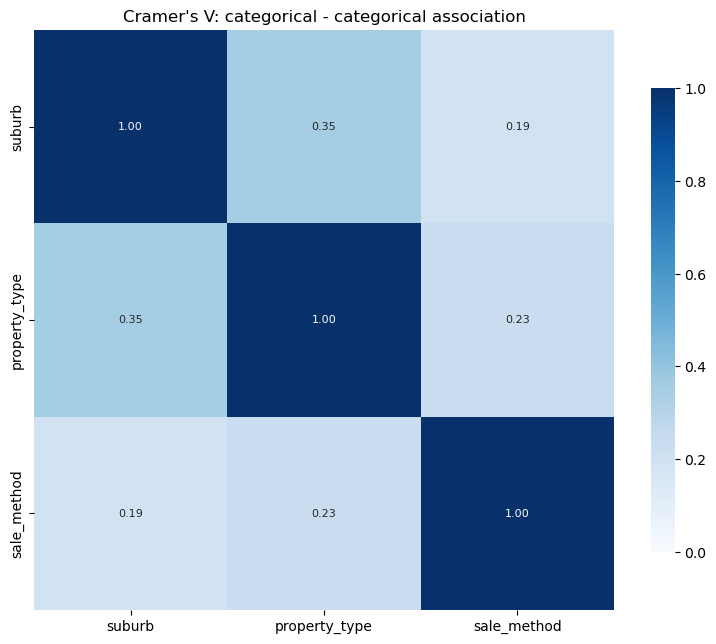

In [16]:
cat_cols = ["suburb", "property_type", "sale_method"]

def cramer_v(x, y):
    contingency = pd.crosstab(x, y)
    if min(contingency.shape) < 2:
        return np.nan
    chi2 = stats.chi2_contingency(contingency, correction = False).statistic
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

cat_train = df[cat_cols]

cramer_matrix = pd.DataFrame(
    [[cramer_v(cat_train[a], cat_train[b]) for b in cat_train.columns] for a in cat_train.columns],
    index = cat_train.columns,
    columns = cat_train.columns
)

fig, ax = plt.subplots(figsize = (8, 6.5))
sns.heatmap(
    cramer_matrix, annot = True, fmt = ".2f", cmap = "Blues", vmin = 0, vmax = 1,
    square = True, annot_kws = {"size": 8}, cbar_kws = {"shrink": 0.8}, ax = ax
)
ax.set_title("Cramer's V: categorical - categorical association")
plt.tight_layout()
plt.show()

## Our guess of three indicative features

- `suburb`: location dominated every price comparison in the EDA, and the three suburbs differ in terms of median prices.

- `property_type`: houses and units are priced by different logic, which is the assumption `is_unit` was engineered on in the later stage.

- **price tercile**: derived from the target itself, it exposes whether accuracy depends on where in the price range a property sits, which no single input feature reveals on its own.

## Rationale for each engineered feature

- `is_unit` — $\mathbb{1}[\texttt{property\_type} \neq \texttt{"House"}]$

The number of data instances are insufficient, as compared to `property_type`. The `OneHotEncoder` mau introduce near-empty categories, which cause the models harder to learn the patterns from the data and unnecessarily increase the number of features in the data.

- `t` — `days_since_epoch`

Turn to float rather than binned to keep the trend smooth and monotone.

- `month` — `sold_date.dt.month`

Intended to capture auction-calendar seasonality.

- `bed_bath` — $\texttt{bedrooms} + 0.5 \times \texttt{bathrooms}$

As can be seen in the correlation matrix above, `bedrooms` and `bathrooms` move together, said differently `bedrooms` and `bathrooms` are moderately correlated, but are not redundant, , we shall engineer them into once feature to avoid multicollinearity effect.

- `beds_x_unit` — $\texttt{bedrooms} \times \texttt{is\_unit}$

An interaction letting the marginal value of a bedroom differ by dwelling type, since a three-bedroom apartment and a three-bedroom house are not the same product.


- `kw_renovated`, `kw_view`, `kw_potential`, `kw_modern`, `kw_original`, `kw_pool`

We extract from the property's description to derive these binary columns. Binary flags recovering condition and amenity signal that appears in agent copy but has no structured column. However `str.contains` is unanchored (`kw_view` fires on "review" and "overview").



In [17]:
def engineer(d):
    d = d.copy()
    d["is_unit"]      = (d.property_type != "House").astype(int)
    d["t"]            = d.days_since_epoch.astype(float)
    d["month"]        = d.sold_date.dt.month
    d["bed_bath"]     = d.bedrooms + 0.5*d.bathrooms
    d["beds_x_unit"]  = d.bedrooms * d.is_unit
    for kw in ["renovated", "view", "potential", "modern", "original", "pool"]:
        d[f"kw_{kw}"] = d.description.str.lower().str.contains(kw).astype(int)
    return d

df = engineer(df)

## Feature selection

Before moving forward, we also note that, there are some columns in our dataset that are used to store description and where the property's datum was extracted from. These are unimportant in our notebook, and hence, we shall drop these redundant columns. For brevity, the following columns are retained for modeling purpose.

In [18]:
num_cols = ["area_sqm", "bedrooms", "bathrooms", "parking", "bed_bath",
       "beds_x_unit", "is_unit", "t", "month"] + \
      [c for c in df.columns if c.startswith("kw_")]

cat_cols = ["suburb", "property_type", "sale_method"]

In [19]:
kept_cols = num_cols + cat_cols + ["price_aud"]
df = df[kept_cols]
df.head(5)

,area_sqm,bedrooms,bathrooms,parking,bed_bath,beds_x_unit,is_unit,t,month,kw_renovated,kw_view,kw_potential,kw_modern,kw_original,kw_pool,suburb,property_type,sale_method,price_aud
0,84.0,2.0,1,1.0,2.5,2.0,1,228.0,8,0,0,0,0,1,0,Blacktown,Apartment,Private treaty,419000
1,NaN,3.0,1,1.0,3.5,0.0,0,228.0,8,0,0,0,0,1,0,Blacktown,House,Private treaty,910000
2,NaN,2.0,2,1.0,3.0,2.0,1,222.0,8,0,0,0,1,0,0,Blacktown,Apartment,Private treaty,491000
3,556.0,3.0,1,1.0,3.5,0.0,0,222.0,8,0,0,0,0,0,0,Blacktown,House,Private treaty,1030000
4,562.0,3.0,1,1.0,3.5,0.0,0,219.0,8,0,0,1,0,0,0,Blacktown,House,Auction,900000


# Model Development and Evaluation

We leverage three different regression models with three different modeling approaches to observe how good they fit the proposed dataset.

- Ridge Linear Regression: chosen due to its simplicity and straightforward interpretability, L2 to penalise outliers.

- Random Forest: chosen due to Bagging-based family.

- AdaBoost: chosen due to Boosting-based family and benchmark against Bagging-based methods.

**Note:** as can be seen earlier, the pricing distribution is heavily right-skewed, we shall train model on log-scaled price instead of raw prices.

Let us clarify more about our choice of models. The three are chosen to represent genuinely different inductive biases rather than three variants of one idea:

- **Ridge**: a regularised linear model. With $n=188$ and one-hot encoded categoricals the design matrix is wide relative to the sample, and the L2 penalty is what keeps correlated inputs such as `bedrooms`, `bathrooms` and `bed_bath` from producing unstable coefficients.

- **Random Forest**: bagged trees. Captures interactions and non-linearity without being told where they are, and averaging over deep trees controls the variance that a single tree would have on a sample this small.

- **AdaBoost**: boosted trees. Fits residuals sequentially, so it can chase structure the other two miss, at the cost of being the most sensitive of the three to noisy or atypical records.

**Prediction.** We expect the tree ensembles to win. The dataset is small, mixes categorical and numeric inputs, and its price surface is plainly non-linear across three very different suburbs.

## Preprocessing and modeling pipeline

In [20]:
def make_pre():
    return ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy = "median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown = "ignore", min_frequency = 3), cat_cols)
    ])

In [21]:
MODELS = {
    "Ridge": Pipeline([
        ("pre", make_pre()),
        ("m", Ridge(random_state = RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("pre", make_pre()),
        ("m", RandomForestRegressor(n_jobs = -1, random_state = RANDOM_STATE))
    ]),
    "AdaBoost": Pipeline([
        ("pre", make_pre()),
        ("m", AdaBoostRegressor(random_state = RANDOM_STATE))
    ])
}

## Train and test split

In [22]:
X, y = df.iloc[:, :-1], np.log(df.iloc[:,-1])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = RANDOM_STATE, shuffle = True
)

## Hyperparam tuning

In [24]:
GRIDS = {
    "Ridge": {"m__alpha": np.logspace(-2, 3, 12)},
    "Random Forest": {"m__n_estimators": [50, 100, 200, 300, 400],
                      "m__max_depth": [None, 1, 2, 3, 4, 6],
                      "m__min_samples_leaf": [1, 2, 3, 4]},
    "AdaBoost": {"m__n_estimators": [50, 100, 200, 300, 400, 500],
                      "m__learning_rate": [0.01, 0.05, 0.1]},
}

cv = KFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

best = {}
for name, pipe in MODELS.items():
    gs = GridSearchCV(pipe, GRIDS[name], cv = cv,
                      scoring = "neg_root_mean_squared_error", n_jobs = -1)
    best[name] = gs.fit(X_train, y_train)

tuning = pd.DataFrame({
    "best_params": {k: g.best_params_ for k, g in best.items()},
})

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", None
):
    display(tuning)

,best_params
Ridge,{'m__alpha': 0.23101297000831592}
Random Forest,"{'m__max_depth': 4, 'm__min_samples_leaf': 3, 'm__n_estimators': 100}"
AdaBoost,"{'m__learning_rate': 0.05, 'm__n_estimators': 300}"


In [25]:
def cv_evaluate(pred, truths):
    # pred/truths are log AUD, so rmse/mae/medae are in log units.
    # MAPE is only meaningful as a share of a price, so it is taken after exp().
    return pd.Series({
        "cv_rmse":  root_mean_squared_error(truths, pred),
        "cv_mape%": mean_absolute_percentage_error(np.exp(truths), np.exp(pred)) * 100,
        "cv_mae":   mean_absolute_error(truths, pred),
        "cv_medae": median_absolute_error(truths, pred),
        "cv_r2":    r2_score(truths, pred),
    })

cv_metrics = pd.DataFrame({
    name: cv_evaluate(
        cross_val_predict(g.best_estimator_, X_train, y_train, cv = cv, n_jobs = -1),
        y_train
    )
    for name, g in best.items()
}).T.sort_values("cv_rmse")

cv_metrics.round(4)

,cv_rmse,cv_mape%,cv_mae,cv_medae,cv_r2
Ridge,0.2055,16.7793,0.1652,0.1505,0.9131
Random Forest,0.2170,16.9657,0.1705,0.1533,0.9030
AdaBoost,0.2257,18.1515,0.1814,0.1665,0.8951


,R2_log_train,R2_log_cv,gap
Ridge,0.9358,0.9131,0.0227
Random Forest,0.9411,0.9030,0.0380
AdaBoost,0.9321,0.8951,0.0370


Lowest cross-validated MAPE: Ridge (16.78%)


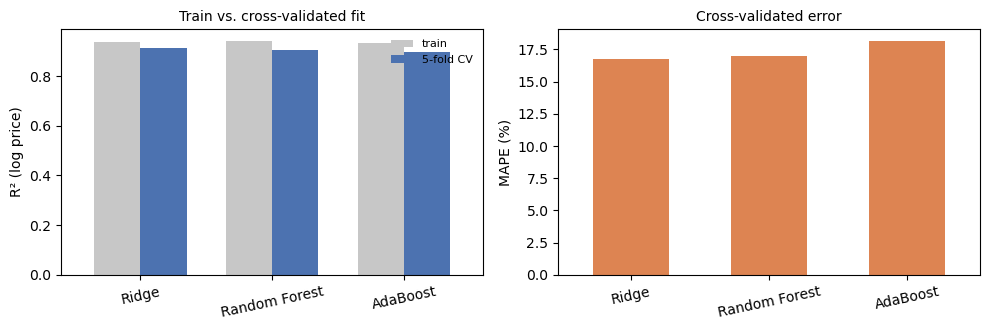

In [26]:
# In-sample R2 (R2_log_train) alongside the out-of-fold R2 (R2_log_cv) already in cv_metrics.
fit_gap = pd.DataFrame({
    "R2_log_train": {n: r2_score(y_train, g.best_estimator_.predict(X_train)) for n, g in best.items()},
    "R2_log_cv":    cv_metrics["cv_r2"],
})

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
fit_gap.plot.bar(ax=ax[0], color=["#C7C7C7","#4C72B0"], rot=12, width=.7)
ax[0].set_ylabel("R² (log price)"); ax[0].set_title("Train vs. cross-validated fit", fontsize=10)
ax[0].legend(["train", f"{cv.get_n_splits()}-fold CV"], frameon=False, fontsize=8)

cv_metrics["cv_mape%"].plot.bar(ax=ax[1], color="#DD8452", rot=12, width=.55)
ax[1].set_ylabel("MAPE (%)"); ax[1].set_title("Cross-validated error", fontsize=10)
plt.tight_layout()

display(fit_gap.assign(gap = lambda d: d.R2_log_train - d.R2_log_cv).round(4))

lowest = cv_metrics["cv_mape%"].idxmin()
print(f"Lowest cross-validated MAPE: {lowest} ({cv_metrics.loc[lowest, 'cv_mape%']:.2f}%)")

## Learning Capacity vs. training samples

In [27]:
def plot_learning_curve(model, X_tr, y_tr, title, ax):
    sizes, train_scores, cv_scores = learning_curve(
        model, X_tr, y_tr, cv = cv, scoring = "neg_root_mean_squared_error",
        train_sizes = np.linspace(0.2, 1.0, 5), n_jobs = -1
    )
    train_scores *= -1
    cv_scores *= -1

    ax.plot(sizes, train_scores.mean(axis = 1), "o-", label = "training")
    ax.plot(sizes, cv_scores.mean(axis = 1), "s-", label = "cross-validation")
    # Construct the confidence interval
    ax.fill_between(sizes, cv_scores.mean(1) - cv_scores.std(1),
                    cv_scores.mean(1) + cv_scores.std(1), alpha = 0.15)
    ax.set(xlabel = "Training samples", ylabel = "", title = title)
    ax.grid(axis = "y", visible = True)
    ax.set_axisbelow(True)
    ax.legend(loc = "upper right")

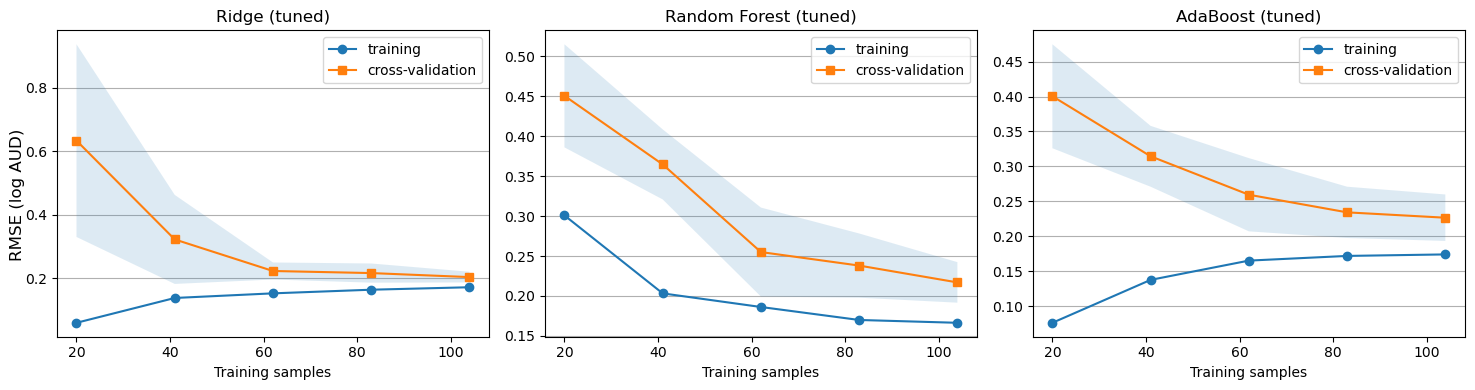

In [28]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

plot_learning_curve(best["Ridge"].best_estimator_, X_train, y_train, "Ridge (tuned)", axes[0])
plot_learning_curve(best["Random Forest"].best_estimator_, X_train, y_train, "Random Forest (tuned)", axes[1])
plot_learning_curve(best["AdaBoost"].best_estimator_, X_train, y_train, "AdaBoost (tuned)", axes[2])

fig.supylabel("RMSE (log AUD)")
plt.tight_layout()
plt.show()

## Residual behaviour across models

We compare how each tuned model's residuals behave against the ground-truth price, using
out-of-fold predictions so the held-out test set stays untouched. The question is not only which model has the lowest average error, but also whether its errors are *evenly spread*, i,e. a model whose residuals widen at one end of the price range is unreliable exactly where the stakes are highest.

Residuals are reported as $\log(\text{actual}/\text{predicted})$, which is scale-free and therefore comparable across the three suburbs. Note that, we apply the same set of out-of-fold points, which make the plots comparable.

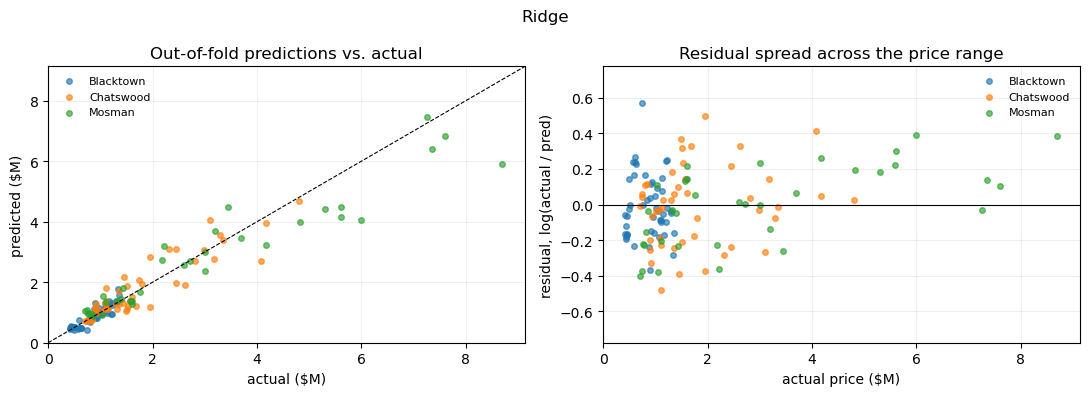

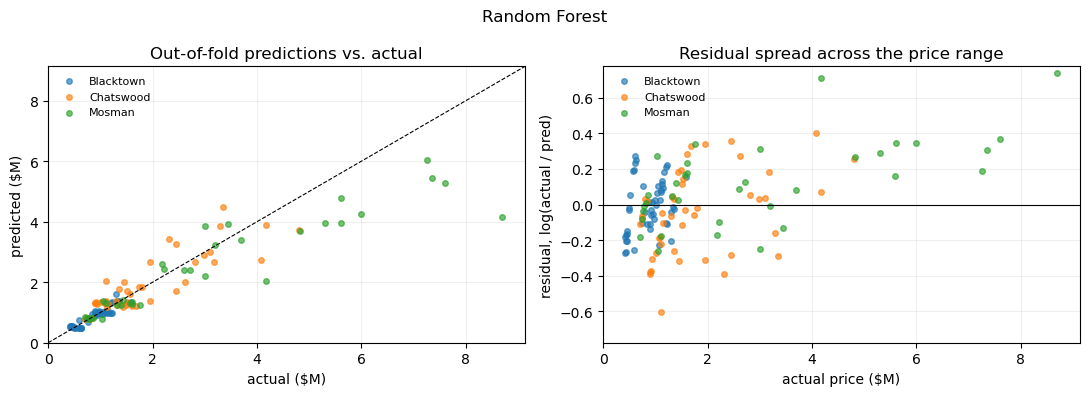

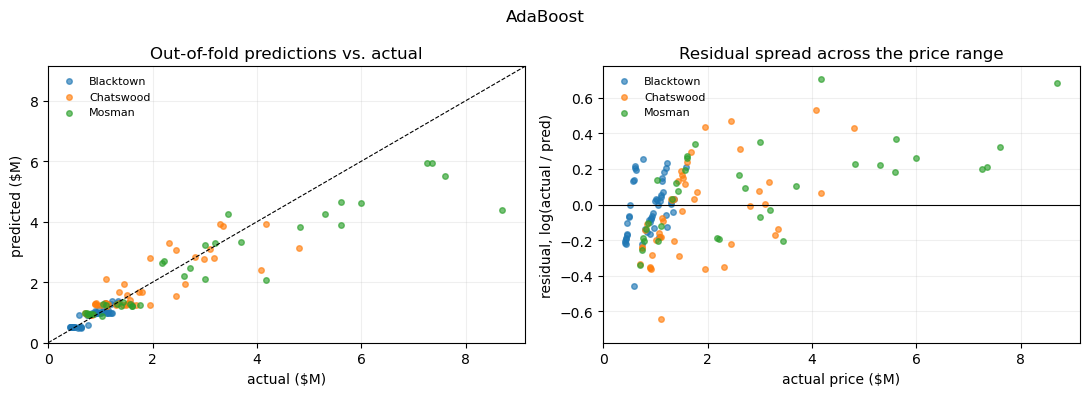

Mean |log residual| by suburb:


,Ridge,Random Forest,AdaBoost
Blacktown,0.1416,0.1237,0.1260
Chatswood,0.1758,0.1955,0.2101
Mosman,0.1850,0.2046,0.2228


Does the error scale with price?


,corr
Ridge,0.095
Random Forest,0.416
AdaBoost,0.330


In [29]:
# Out-of-fold predictions, so model comparison never touches the test set.
oof = {name: cross_val_predict(g.best_estimator_, X_train, y_train, cv = cv, n_jobs = -1)
       for name, g in best.items()}

actual  = np.exp(y_train).values
suburbs = X_train.suburb.values

SUBURBS = sorted(pd.unique(suburbs))
PAL = dict(zip(SUBURBS, sns.color_palette("tab10", len(SUBURBS))))

lim  = [0, actual.max()/1e6 * 1.05]
rmax = max(np.abs(y_train.values - p).max() for p in oof.values()) * 1.05

for name, p in oof.items():
    resid = y_train.values - p

    fig, ax = plt.subplots(1, 2, figsize = (11, 4))
    fig.suptitle(name, fontsize = 12)

    for s in SUBURBS:
        m = suburbs == s
        ax[0].scatter(actual[m]/1e6, np.exp(p[m])/1e6, s = 16, alpha = .65,
                      color = PAL[s], label = s)
        ax[1].scatter(actual[m]/1e6, resid[m], s = 16, alpha = .65,
                      color = PAL[s], label = s)

    ax[0].plot(lim, lim, "k--", lw = .8)
    ax[0].set(xlim = lim, ylim = lim, xlabel = "actual ($M)", ylabel = "predicted ($M)",
              title = "Out-of-fold predictions vs. actual")

    ax[1].axhline(0, color = "k", lw = .8)
    ax[1].set(xlim = lim, ylim = (-rmax, rmax), xlabel = "actual price ($M)",
              ylabel = "residual, log(actual / pred)",
              title = "Residual spread across the price range")

    for a in ax:
        a.grid(alpha = .2); a.set_axisbelow(True)
        a.legend(frameon = False, fontsize = 8)

    plt.tight_layout()
    plt.show()

abs_resid = pd.DataFrame({name: np.abs(y_train.values - p) for name, p in oof.items()})

print("Mean |log residual| by suburb:")
display(abs_resid.groupby(suburbs).mean().round(4))

print("Does the error scale with price?")
display(abs_resid.corrwith(pd.Series(actual)).round(3).to_frame("corr"))

**Recommendation.** `Ridge` is the most appropriate model for this dataset.

Our prior expectation was that the tree ensembles would win, and the results did not support it. `Ridge` leads on every cross-validated metric (`cv_rmse` 0.2055 against 0.2170 and 0.2257, `cv_mape%` 16.78 against 16.97 and 18.15), and the gap between training and out-of-fold $R^2$ is narrowest for `Ridge`, so it is also the least over-fitted of the three. Most importantly, in `Random Forest` and `AdaBoost`, the absolute residual is correlated with the actual price, suggesting a stronger rise in errors if the price is getting higher.

# Investigating Prediction Failures

In [30]:
est = best["Ridge"].best_estimator_

In [31]:
pred_log = est.predict(X_test)

err = X_test.copy()
err["actual_aud"] = np.exp(y_test)
err["pred_aud"]   = np.exp(pred_log)
err["resid_log"]  = y_test - pred_log                 # log(actual / pred)
err["err_pct"]    = 100 * (err.actual_aud - err.pred_aud) / err.actual_aud
err["abs_pct"]    = err.err_pct.abs()

cols = ["suburb", "property_type", "bedrooms", "bathrooms",
        "actual_aud", "pred_aud", "err_pct", "resid_log"]

# Ranked on the log residual, so the list is not just the most expensive homes.
err.reindex(err.resid_log.abs().sort_values(ascending = False).index)[cols].head(5).round(2)

,suburb,property_type,bedrooms,bathrooms,actual_aud,pred_aud,err_pct,resid_log
155,Mosman,Apartment,1.0,1,1570000.0,845910.81,46.12,0.62
93,Chatswood,Apartment,3.0,3,1385888.0,2365822.90,-70.71,-0.53
127,Chatswood,Apartment,2.0,2,2150000.0,1300158.87,39.53,0.50
16,Blacktown,House,3.0,2,1000000.0,1516701.27,-51.67,-0.42
100,Chatswood,Apartment,1.0,1,1030000.0,703931.91,31.66,0.38


Looking at the above table, we cannot conclude our model fails; in fact, they can be outliers of the dataset. If those five sales were genuine outliers, their errors would be isolated. Alternatively, if an error of similar size recurs across a whole group of properties, the model is wrong about that group systematically, and the cause is a
missing feature rather than five unlucky sales.

To separate the two, we aggregate the errors over three aforementioned indicative features, i.e. `suburb`, `property_type`, and **price tercile**. An error pattern that persists across these groupings is structural; one that disappears once the rows are pooled is a handful of outliers.

In [32]:
def segment(by):
    return err.groupby(by, observed = True).agg(
        n = ("abs_pct", "size"),
        mean_abs_pct = ("abs_pct", "mean"),
        bias_pct = ("err_pct", "mean"),      # signed: negative = over-prediction
    ).round(1)

for by in ["suburb", "property_type", pd.qcut(err.actual_aud, 3, labels = ["low", "mid", "high"])]:
    display(segment(by))

,n,mean_abs_pct,bias_pct
suburb,,,
Blacktown,29,11.7,-4.9
Chatswood,16,25.6,-6.2
Mosman,12,20.9,-0.5


,n,mean_abs_pct,bias_pct
property_type,,,
Apartment,30,21.9,-4.3
House,21,12.9,-6.0
Retirement living,2,17.3,8.6
Townhouse,3,11.0,-4.5
Villa,1,3.3,3.3


,n,mean_abs_pct,bias_pct
actual_aud,,,
low,19,13.7,-10.8
mid,19,17.2,-4.1
high,19,21.7,1.9


**Where the model fails.**

- **By suburb**: Blacktown 11.7% vs Chatswood 25.6%. Chatswood is the worst despite sitting mid-range on price, so this is not simply a tail problem.

- **By type**: apartments 21.9% vs houses 12.9%. Four of the five worst predictions are apartments.

- **By price**: error rises from 13.7% (low tercile) to 21.7% (high), and `bias_pct` flips from −10.8% to +1.9%: cheap homes are over-priced by the model, expensive ones slightly under-priced.

The single worst case is a 1-bed Mosman apartment that sold for \$1.57M against a \$846k prediction. With `area_sqm` missing for this property and median-imputed, a 1-bed/1-bath apartment is nearly indistinguishable from any other in the feature set, so the model cannot see the view or position that justified the price. This can be in fact, considered an outlier, rather than a model failure.

## Keeping versus dropping incomplete rows

The rule in Part 1 discarded 51 properties, 27 of them in Mosman, the suburb the model already
handles worst. That is a real cost, and it was asserted rather than tested. Here we test it: each
model is re-tuned and cross-validated twice under an identical protocol, once on all collected
properties with `area_sqm` and the other gaps imputed inside the pipeline, and once on the filtered
subset. Both runs use the same grids, the same 5-fold splits and the same seed, so the only
difference is which rows are present.

In [33]:
def cv_on(frame, label):
    """Re-tune and cross-validate every model on `frame`, under one identical protocol."""
    d = engineer(frame)
    X, y = d[num_cols + cat_cols], np.log(d["price_aud"])
    out = {}
    for name, pipe in MODELS.items():
        gs  = GridSearchCV(pipe, GRIDS[name], cv = cv,
                           scoring = "neg_root_mean_squared_error", n_jobs = -1).fit(X, y)
        oof = cross_val_predict(gs.best_estimator_, X, y, cv = cv, n_jobs = -1)
        out[name] = {
            "n":        len(d),
            "cv_rmse":  root_mean_squared_error(y, oof),
            "cv_mape%": mean_absolute_percentage_error(np.exp(y), np.exp(oof)) * 100,
            "cv_r2":    r2_score(y, oof),
        }
    return pd.DataFrame(out).T.assign(rows = label)

keep = cv_on(df_full, "keep all")
drop = cv_on(df_full.dropna(subset = REQUIRED), "drop -> filtered")

comparison = (pd.concat([keep, drop])
                .set_index("rows", append = True)
                .reorder_levels([1, 0])
                .sort_index())
display(comparison.round(4))

delta = drop["cv_rmse"] - keep["cv_rmse"]
print("change in cv_rmse from dropping (negative = dropping is better):")
print(delta.round(4).to_string())

n  cv_rmse  cv_mape%   cv_r2
rows                                                            
drop -> filtered AdaBoost       188.0   0.2341   18.9855  0.8708
                 Random Forest  188.0   0.2226   17.2611  0.8832
                 Ridge          188.0   0.2069   16.2889  0.8991
keep all         AdaBoost       239.0   0.2436   19.9788  0.8703
                 Random Forest  239.0   0.2289   17.3655  0.8855
                 Ridge          239.0   0.2235   17.5044  0.8908

change in cv_rmse from dropping (negative = dropping is better):
Ridge           -0.0166
Random Forest   -0.0063
AdaBoost        -0.0095


# Final Deployment and Reflection

## Held-out test performance

Every figure so far came from cross-validation on the training split, and those same folds chose
the hyperparameters, so they are mildly optimistic. The test set has been untouched until now and
is the one honest estimate of performance on unseen sales.

In [34]:
final_test = cv_evaluate(est.predict(X_test), y_test).rename("Ridge (held-out test)")

display(final_test.to_frame().round(4))
print(f"Typical multiplicative error: x{np.exp(final_test['cv_rmse']):.3f} "
      f"(about +/-{100*(np.exp(final_test['cv_rmse'])-1):.0f}%)")

,Ridge (held-out test)
cv_rmse,0.2199
cv_mape%,17.5137
cv_mae,0.1715
cv_medae,0.1425
cv_r2,0.8096


Typical multiplicative error: x1.246 (about +/-25%)


## Exporting the model

In [35]:
deployed = clone(est).fit(X, y)              # X, y = all 188 rows
final_test = cv_evaluate(est.predict(X_test), y_test).rename("Ridge (held-out test)")

bundle = {
    "pipeline":     deployed,
    "num":          num_cols,
    "cat":          cat_cols,
    "model_name":   "Ridge (alpha=%.3f)" % deployed.named_steps["m"].alpha,
    "trained_rows": len(X),
    "suburbs":      sorted(df.suburb.unique()),
    "target":       "log(price_aud)  ->  exp() the prediction for AUD",
    "test_mape":    float(final_test["cv_mape%"]),
    "epoch":        "t = days since 2026-01-01",
}

out = Path("../src/model.joblib")
joblib.dump(bundle, out)
print(f"wrote {out.resolve()}  ({out.stat().st_size/1e3:.1f} kB)")

wrote /Users/admin/Deakin/Year_3/T2:2026/SIT307 - Machine Learning/Portfolio/Distinction/src/model.joblib  (5.5 kB)


## The web application

`src/app.py` is a Streamlit prototype that loads `src/model.joblib` and never re-trains. It offers
two modes:

- A form for a single property.
- A CSV upload for batch estimates.

Inputs are the fields an agent can read off a listing, i.e. `suburb`, `property_type`, `bedrooms`, `bathrooms`, `car_spaces`, `sale_date`, and optionally the marketing description, from which the `kw_*` flags are recreated with the same rules used in `engineer()`. Derived terms (`bed_bath`, `beds_x_unit`, `is_unit`, `t`, `month`) are computed in the app from those raw inputs.

Because the model predicts on the log scale, the app exponentiates before display and shows an indicative ±20% band rather than a single figure, which reflects the measured error honestly.

**To run:**

```bash
pip install streamlit scikit-learn pandas numpy joblib
streamlit run src/app.py          # from the project root
```